In [1]:
from datasets import load_dataset

# duration : 1min20
ds = load_dataset("imageomics/Hawaii-beetles")

c:\Users\tombe\Documents\_MLE\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
print(ds)          # split(s), nombre d'exemples
print(ds["train"].features)  # structure des features (colonnes, types)

DatasetDict({
    train: Dataset({
        features: ['image', 'taxonID', 'scientificName', 'plotID', 'trapID', 'plotTrapID', 'collectDate', 'ownerInstitutionCode', 'catalogNumber', 'individualImageFilePath', 'groupImageFilePath', 'individualID'],
        num_rows: 1614
    })
})
{'image': Image(mode=None, decode=True), 'taxonID': Value('large_string'), 'scientificName': Value('large_string'), 'plotID': Value('int64'), 'trapID': Value('large_string'), 'plotTrapID': Value('large_string'), 'collectDate': Value('int64'), 'ownerInstitutionCode': Value('large_string'), 'catalogNumber': Value('large_string'), 'individualImageFilePath': Value('large_string'), 'groupImageFilePath': Value('large_string'), 'individualID': Value('large_string')}


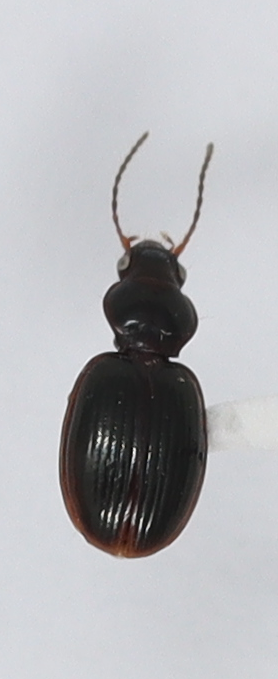

In [3]:
example = ds["train"][0]
example["image"]          # objet PIL ou array


In [6]:
from datasets import load_dataset
from pathlib import Path
from PIL import Image
import tqdm

def save_all_hawaii_beetles_images(out_dir: str, split: str = "train", image_column: str = None):
    out_dir = Path(out_dir)
    out_dir.mkdir(parents=True, exist_ok=True)

    ds = load_dataset("imageomics/Hawaii-beetles", split=split)

    # Parcours et sauvegarde
    for i, example in tqdm.tqdm(enumerate(ds), total=len(ds)):
        img = example["image"]

        if hasattr(img, "save"):
            if "individualImageFilePath" in example:
                rel_path = Path(example["individualImageFilePath"])
            else:
                rel_path = Path(f"image_{i:06d}.png")

            dst_path = out_dir / rel_path
            dst_path.parent.mkdir(parents=True, exist_ok=True)
            img.save(dst_path)
        else:
            raise TypeError(f"Image type not generated for item {i}: {type(img)}")

    print("Download finished")


In [ ]:
# Exemple d'utilisation :
save_all_hawaii_beetles_images("hawaii_beetles_images")


100%|██████████| 1614/1614 [01:23<00:00, 19.42it/s]

Download finished
